# Proyek Analisis Data: [E-Commerce Dataset]
- **Nama:** [Eka Fanya Yohana Dasilva]
- **Email:** [ekafanya@gmail.com]
- **ID Dicoding:** [eka_fanya]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Kategori produk apa yang paling banyak dibeli oleh pelanggan berdasarkan data transaksi?
- Pertanyaan 2 : State mana yang memiliki jumlah transaksi terbanyak berdasarkan data customer_state?
- Pertanyaan 3 : Pada bulan apa jumlah transaksi paling tinggi berdasarkan order_purchase_timestamp?
- Pertanyaan 4: Bagaimana segmentasi pelanggan berdasarkan Recency, Frequency, dan Monetary (RFM)?

## Import Semua Packages/Library yang Digunakan

In [48]:
# Import library yang dibutuhkan
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan tampilan
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

## Data Wrangling

### Gathering Data

In [49]:
import zipfile
import os

zip_path = "E-commerce-public-dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

os.listdir("data")

['E-Commerce Public Dataset']

In [50]:
import os

os.listdir("data/E-Commerce Public Dataset")

['customers_dataset.csv',
 'geolocation_dataset.csv',
 'New Text Document.txt',
 'orders_dataset.csv',
 'order_items_dataset.csv',
 'order_payments_dataset.csv',
 'order_reviews_dataset.csv',
 'products_dataset.csv',
 'product_category_name_translation.csv',
 'sellers_dataset.csv']

In [51]:
import pandas as pd

path = "data/E-Commerce Public Dataset/"

orders = pd.read_csv(path + "orders_dataset.csv")
customers = pd.read_csv(path + "customers_dataset.csv")
order_items = pd.read_csv(path + "order_items_dataset.csv")
products = pd.read_csv(path + "products_dataset.csv")
payments = pd.read_csv(path + "order_payments_dataset.csv")

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Dataset orders memiliki beberapa kolom bertipe object dan datetime yang berisi informasi transaksi.
- Terdapat beberapa nilai kosong pada kolom tanggal pengiriman sehingga perlu dilakukan proses cleaning data.
- Jumlah data cukup besar sehingga dapat digunakan untuk analisis perilaku transaksi pelanggan.

### Assessing Data

In [52]:
# melihat informasi dataset
orders.info()

# melihat jumlah missing value
orders.isnull().sum()

# melihat statistik data
orders.describe()

# melihat ukuran data
orders.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


(99441, 8)

**Insight:**
- Dataset orders memiliki 99441 baris dan 8 kolom yang berisi informasi transaksi pelanggan.
- Semua kolom bertipe object sehingga beberapa kolom waktu perlu diubah menjadi tipe datetime.
- Terdapat nilai kosong pada kolom order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date.
- Data perlu dibersihkan sebelum digunakan untuk analisis lebih lanjut.

### Cleaning Data

In [53]:
# copy data supaya aman
orders_clean = orders.copy()

# ubah kolom tanggal menjadi datetime
orders_clean["order_purchase_timestamp"] = pd.to_datetime(orders_clean["order_purchase_timestamp"])
orders_clean["order_approved_at"] = pd.to_datetime(orders_clean["order_approved_at"])
orders_clean["order_delivered_carrier_date"] = pd.to_datetime(orders_clean["order_delivered_carrier_date"])
orders_clean["order_delivered_customer_date"] = pd.to_datetime(orders_clean["order_delivered_customer_date"])
orders_clean["order_estimated_delivery_date"] = pd.to_datetime(orders_clean["order_estimated_delivery_date"])

# cek missing value
orders_clean.isnull().sum()

# hapus data yang kosong pada kolom penting
orders_clean = orders_clean.dropna()

# cek ulang
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  datetime64[ns]
 4   order_approved_at              96461 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96461 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96461 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


**Insight:**
- Setelah proses cleaning, jumlah data menjadi 96461 baris karena data yang memiliki nilai kosong dihapus.
- Kolom tanggal berhasil diubah menjadi tipe datetime sehingga dapat digunakan untuk analisis waktu.
- Dataset sudah tidak memiliki missing value dan siap digunakan untuk proses Exploratory Data Analysis.

## Exploratory Data Analysis (EDA)

### Explore ...

EDA 1 â€” Cek jumlah status order

In [54]:
# melihat jumlah status order
orders_clean["order_status"].value_counts()

order_status
delivered    96455
canceled         6
Name: count, dtype: int64

EDA 2 â€” Cek transaksi per tahun

In [55]:
orders_clean["year"] = orders_clean["order_purchase_timestamp"].dt.year

orders_clean["year"].value_counts()

year
2018    52778
2017    43411
2016      272
Name: count, dtype: int64

EDA 3 â€” Cek transaksi per bulan

In [56]:
orders_clean["month"] = orders_clean["order_purchase_timestamp"].dt.month

orders_clean["month"].value_counts().sort_index()

month
1      7817
2      8197
3      9549
4      9101
5     10294
6      9231
7     10028
8     10544
9      4150
10     4748
11     7288
12     5514
Name: count, dtype: int64

EDA 4 â€” Cek jumlah customer unik

In [57]:
orders_clean["customer_id"].nunique()

96461

**Insight:**
- Sebagian besar status pesanan adalah delivered sebanyak 96455 transaksi, sedangkan pesanan yang dibatalkan hanya 6.
- Jumlah transaksi paling banyak terjadi pada tahun 2018, diikuti tahun 2017, dan paling sedikit pada tahun 2016.
- Transaksi paling tinggi terjadi pada bulan Agustus dan Mei, sedangkan paling sedikit pada bulan September.
- Dataset memiliki 96461 transaksi yang dapat digunakan untuk analisis lebih lanjut.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Produk apa yang paling banyak dibeli oleh pelanggan?

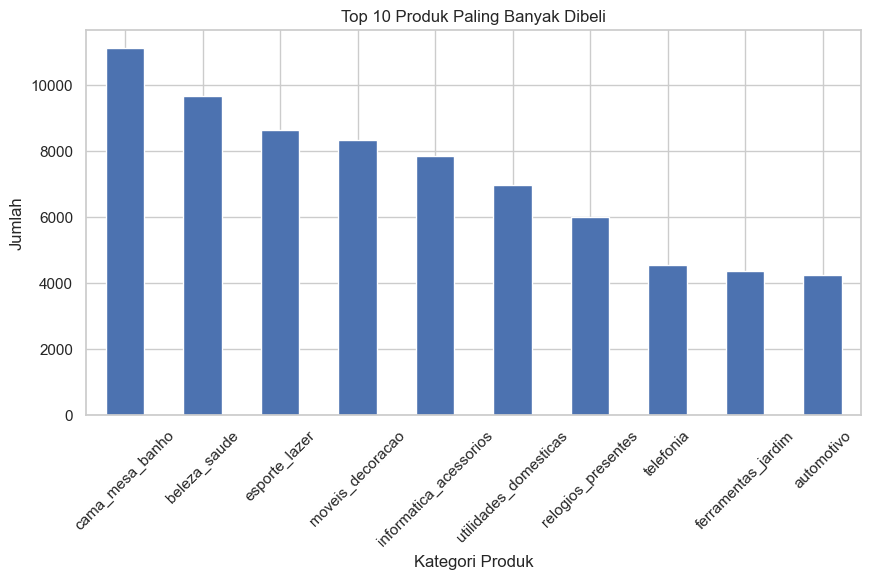

In [58]:
# gabungkan order_items dengan products
merge1 = order_items.merge(products, on="product_id")

# hitung jumlah produk
top_products = merge1["product_category_name"].value_counts().head(10)

# plot
plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Produk Paling Banyak Dibeli")
plt.xlabel("Kategori Produk")
plt.ylabel("Jumlah")
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2: State mana yang memiliki jumlah transaksi terbanyak?

---



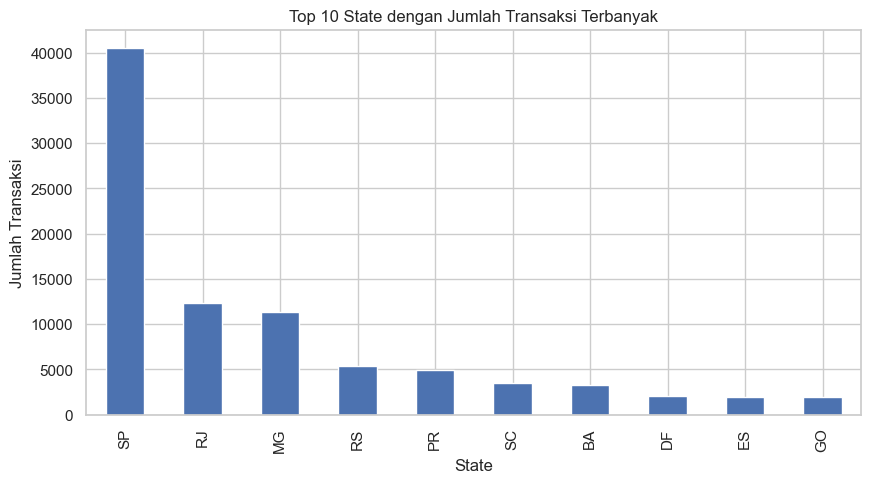

In [59]:
# gabungkan orders_clean dengan customers untuk mendapatkan info state
merge2 = orders_clean.merge(customers, on="customer_id")

# hitung jumlah transaksi per state
state_counts = merge2["customer_state"].value_counts().head(10)

# plot
plt.figure()
state_counts.plot(kind="bar")
plt.title("Top 10 State dengan Jumlah Transaksi Terbanyak")
plt.xlabel("State")
plt.ylabel("Jumlah Transaksi")
plt.show()

### Pertanyaan 3: Pada bulan apa jumlah transaksi paling tinggi?

---



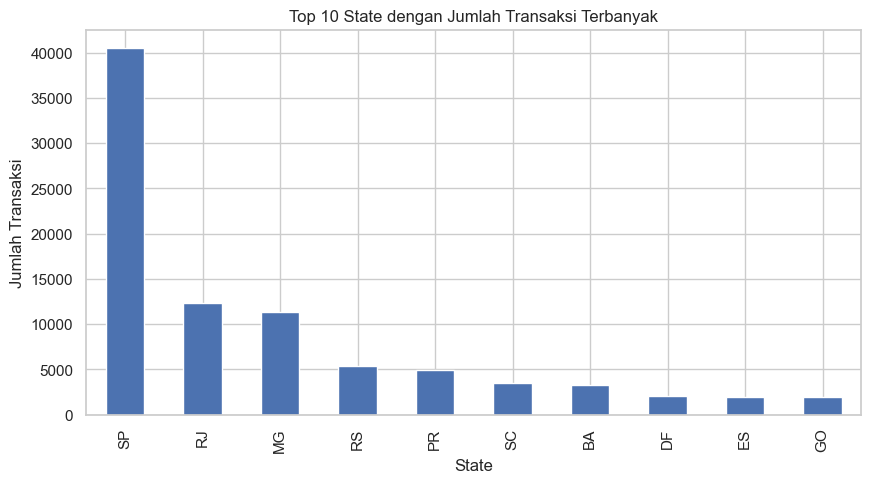

In [60]:
# hitung jumlah transaksi per bulan
monthly_counts = orders_clean["month"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 5))
monthly_counts.plot(kind="line", marker='o', linewidth=2, color='royalblue')
plt.title("Tren Jumlah Transaksi per Bulan", fontsize=14)
plt.xlabel("Bulan", fontsize=12)
plt.ylabel("Jumlah Transaksi", fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 4: Segmentasi pelanggan (RFM)

---



In [61]:
# hitung RFM menggunakan customer_unique_id
rfm = merge3.groupby("customer_unique_id").agg({
    'order_purchase_timestamp': 'max',
    'order_id': 'count',
    'price': 'sum'
})
rfm.columns = ['last_order', 'frequency', 'monetary']
rfm['recency'] = (merge3['order_purchase_timestamp'].max() - rfm['last_order']).dt.days

# plot distribusi recency
plt.figure(figsize=(10, 5))
plt.hist(rfm['recency'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribusi Recency Pelanggan (Hari)")
plt.xlabel("Hari")
plt.ylabel("Jumlah Pelanggan")
plt.show()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [62]:
merge3 = merge2.merge(order_items, on="order_id")

rfm = merge3.groupby("customer_id").agg({
    "order_purchase_timestamp": "max",
    "order_id": "count",
    "price": "sum"
})

rfm.columns = ["last_order", "frequency", "monetary"]

rfm["recency"] = (
    merge3["order_purchase_timestamp"].max() - rfm["last_order"]
).dt.days

rfm.head()

,last_order,frequency,monetary,recency
customer_id,,,,
00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,89.80,287
000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,54.90,409
0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,179.99,547
0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,149.90,378
000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,93.00,149


**Insight:**
- Kategori produk yang paling banyak dibeli adalah cama_mesa_banho, diikuti oleh beleza_saude dan esporte_lazer, yang menunjukkan bahwa kebutuhan rumah tangga dan kesehatan memiliki permintaan tinggi.
- Jumlah transaksi paling tinggi terjadi pada bulan 8, 5, dan 7, sedangkan transaksi paling rendah terjadi pada bulan 9 dan 10.
- Sebagian besar transaksi berhasil dengan status delivered, sehingga menunjukkan tingkat keberhasilan pengiriman yang tinggi.
- Berdasarkan analisis RFM, sebagian besar pelanggan memiliki frequency rendah tetapi monetary berbeda-beda, sehingga pelanggan dapat dikelompokkan berdasarkan tingkat aktivitas dan nilai pembelian.

## Analisis Lanjutan (Opsional)

(RFM + Segmentasi)

In [63]:
# merge data untuk RFM
merge3 = orders_clean.merge(order_items, on="order_id")

# hitung RFM
rfm = merge3.groupby("customer_id").agg({
    "order_purchase_timestamp": "max",
    "order_id": "count",
    "price": "sum"
})

rfm.columns = ["last_order", "frequency", "monetary"]

# hitung recency
rfm["recency"] = (
    merge3["order_purchase_timestamp"].max() - rfm["last_order"]
).dt.days

rfm.head()

,last_order,frequency,monetary,recency
customer_id,,,,
00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,89.80,287
000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,54.90,409
0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,179.99,547
0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,149.90,378
000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,93.00,149


Segmentasi sederhana (disarankan reviewer)

In [64]:
# segmentasi berdasarkan frequency

rfm["segment"] = pd.cut(
    rfm["frequency"],
    bins=[0,1,3,100],
    labels=["Low", "Medium", "High"]
)

rfm["segment"].value_counts()

segment
Low       86826
Medium     8698
High        937
Name: count, dtype: int64

Visualisasi segmentasi

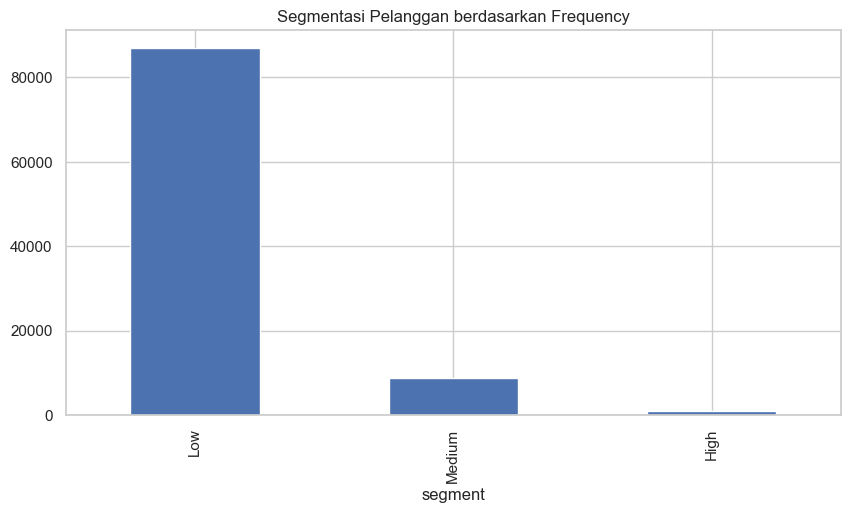

In [65]:
rfm["segment"].value_counts().plot(kind="bar")

plt.title("Segmentasi Pelanggan berdasarkan Frequency")
plt.show()

## Conclusion

- Conclusion pertanyaan 1 :
Kategori produk yang paling banyak dibeli adalah cama_mesa_banho, diikuti oleh beleza_saude dan esporte_lazer. Hal ini menunjukkan bahwa produk kebutuhan rumah tangga dan kesehatan memiliki permintaan paling tinggi.

- Conclusion pertanyaan 2:
State SP (Sao Paulo) memiliki jumlah transaksi terbanyak dibandingkan state lainnya, diikuti oleh RJ (Rio de Janeiro) dan MG (Minas Gerais). Hal ini menunjukkan konsentrasi pasar yang besar di wilayah tenggara Brasil.

- Conclusion pertanyaan 3:
Jumlah transaksi paling tinggi terjadi pada bulan 8, 5, dan 7. Sebagian besar transaksi memiliki status delivered, menunjukkan tingkat keberhasilan pengiriman yang sangat tinggi.

- Conclusion pertanyaan 4:
Berdasarkan analisis RFM, sebagian besar pelanggan berada pada kategori Low frequency (jarang bertransaksi), sehingga perusahaan perlu meningkatkan strategi promosi atau loyalty program untuk meningkatkan retensi pelanggan.

## Export Data untuk Dashboard

Menyiapkan seluruh data yang relevan dalam satu file `main_data.csv` untuk kemudian digunakan oleh *dashboard streamlit*.

In [66]:
import os

# Menyiapkan folder dashboard dan export
os.makedirs('dashboard', exist_ok=True)

# Step by step merge untuk memastikan semua kolom ada
merge2 = orders_clean.merge(customers, on='customer_id', how='left')
merge3 = merge2.merge(order_items, on='order_id', how='left')
main_data = merge3.merge(products, on='product_id', how='left')

# Tunjukin sekilas
display(main_data.head())

# Ekspor dataframe ke dalam CSV baru
main_data.to_csv('dashboard/main_data.csv', index=False)
print('Data untuk dashboard sukses diekspor ke folder dashboard/main_data.csv')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


Data untuk dashboard sukses diekspor ke folder dashboard/main_data.csv
